In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv('bangladesh_telecom.csv')

In [8]:
df['activation_date'] = pd.to_datetime(
    df['activation_date'],
    format='%d/%m/%Y'
)

df['last_recharge_date'] = pd.to_datetime(
    df['last_recharge_date'],
    format='%d/%m/%Y'
)

In [9]:
df['year']=pd.to_datetime(df['activation_date']).dt.year
df['month']=pd.to_datetime(df['activation_date']).dt.month
df['day']=pd.to_datetime(df['activation_date']).dt.day


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            100000 non-null  object        
 1   operator               100000 non-null  object        
 2   plan_type              100000 non-null  object        
 3   region                 100000 non-null  object        
 4   customer_segment       100000 non-null  object        
 5   device_type            100000 non-null  object        
 6   network_type           100000 non-null  object        
 7   internet_plan          100000 non-null  object        
 8   payment_method         100000 non-null  object        
 9   tenure_months          100000 non-null  int64         
 10  monthly_bill_bdt       100000 non-null  float64       
 11  call_minutes_monthly   100000 non-null  float64       
 12  sms_count_monthly      100000 non-null  int64

In [11]:
df.head(3)

,customer_id,operator,plan_type,region,customer_segment,device_type,network_type,internet_plan,payment_method,tenure_months,...,vas_subscribed,auto_renewal,activation_date,last_recharge_date,complaint_type,nps_score,churned,year,month,day
0,BD0000001,Grameenphone,Prepaid,Dhaka,Student,Smartphone (Premium),2G,1GB/day,Auto Debit,73,...,0,0,2022-08-17,2022-01-08,No Complaint,5,1,2022,8,17
1,BD0000002,Teletalk,Prepaid,Chattogram,Student,Smartphone (Budget),4G,2GB/day,Credit Card,2,...,0,0,2022-02-21,2022-04-22,Data Speed,9,0,2022,2,21
2,BD0000003,Banglalink,Prepaid,Dhaka,Student,Feature Phone,5G,5GB/day,Mobile Banking (bKash),1,...,0,0,2023-07-18,2024-06-21,No Complaint,10,0,2023,7,18


In [13]:
df.columns

Index(['customer_id', 'operator', 'plan_type', 'region', 'customer_segment',
       'device_type', 'network_type', 'internet_plan', 'payment_method',
       'tenure_months', 'monthly_bill_bdt', 'call_minutes_monthly',
       'sms_count_monthly', 'data_usage_gb_monthly', 'roaming_enabled',
       'vas_subscribed', 'auto_renewal', 'activation_date',
       'last_recharge_date', 'complaint_type', 'nps_score', 'churned', 'year',
       'month', 'day'],
      dtype='object')

#  Which operator has the highest churn rate?



In [14]:

highest_churn_operator = df[df['churned'] == 1]['operator'].value_counts().idxmax()
print("Highest churn rate customers:", highest_churn_operator)

Highest churn rate customers: Grameenphone


In [15]:
df.groupby('operator')['churned'].count().sort_values(ascending=False).reset_index()

,operator,churned
0,Grameenphone,44978
1,Robi,28144
2,Banglalink,18047
3,Teletalk,4945
4,Airtel,3886


# Which operator generates the highest average monthly revenue per customer (ARPU)?




In [16]:

group=df.groupby('operator')['monthly_bill_bdt'].mean().sort_values(ascending=False).reset_index().rename(columns={'monthly_bill_bdt':'revenue_per_customer'})
group


,operator,revenue_per_customer
0,Airtel,408.350669
1,Robi,405.930550
2,Banglalink,405.417235
3,Grameenphone,404.720658
4,Teletalk,400.381877


# Which regions have the highest customer churn?




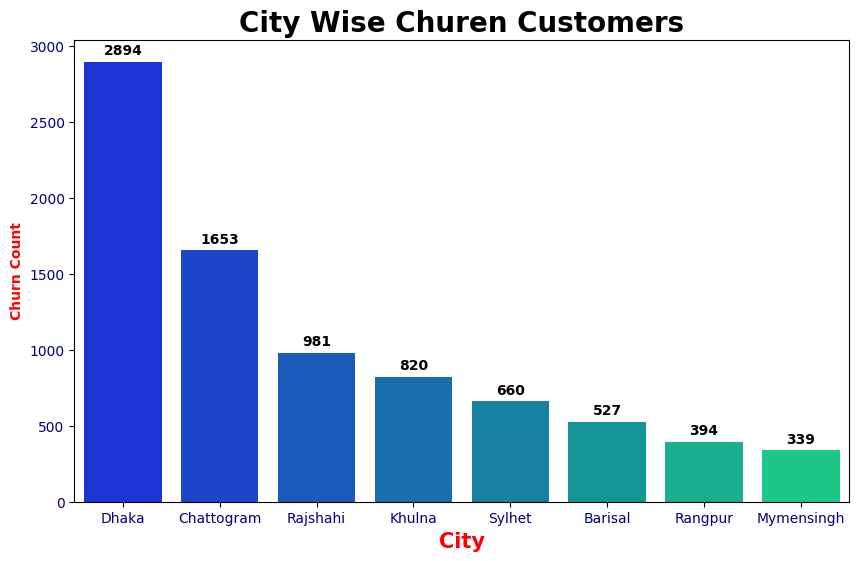

In [17]:
churn_count=df[df['churned']==1]

churn_customer=churn_count.groupby('region')['customer_id'].count().sort_values(ascending=False).reset_index()


plt.figure(figsize=(10,6))
ax=sns.barplot(data=churn_customer,x='region',y='customer_id',palette='winter')
plt.title('City Wise Churen Customers',fontweight='bold',fontsize=20)
plt.xlabel('City',color='red',fontweight='bold',fontsize=15)
plt.ylabel('Churn Count',color='red',fontweight='bold',fontsize=10)
plt.xticks(color='navy')
plt.yticks(color='navy')
for container in ax.containers:
    ax.bar_label(container,padding=3,color='black',fontweight='bold')

# 4. Which customer segments generate the highest revenue?


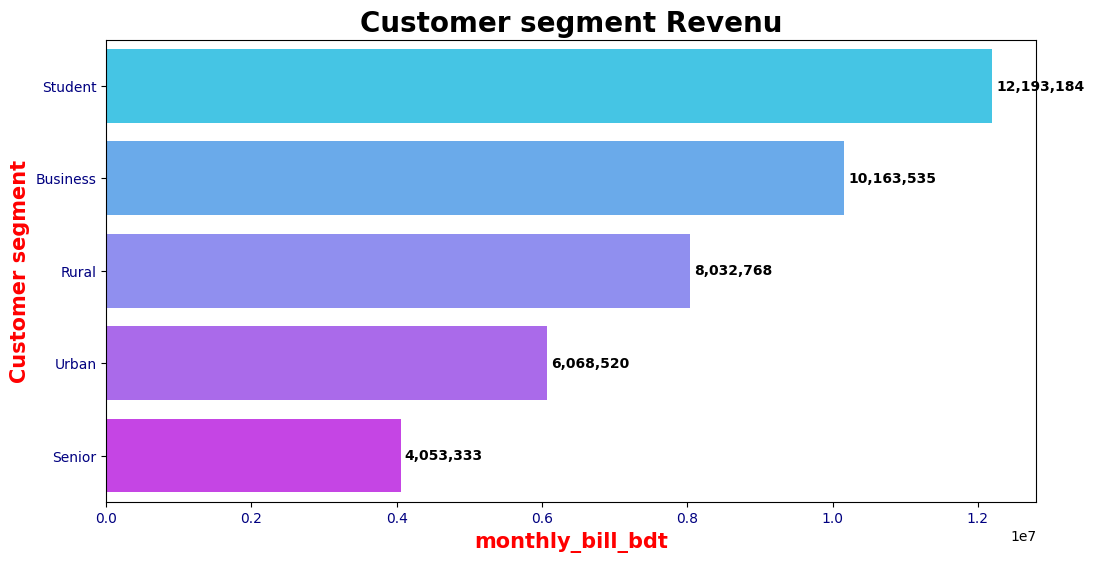

In [18]:
customer_revenu=df.groupby('customer_segment')['monthly_bill_bdt'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,6))
ax=sns.barplot(data=customer_revenu,x='monthly_bill_bdt',y='customer_segment',palette='cool')
plt.title('Customer segment Revenu',fontweight='bold',fontsize=20)
plt.xlabel('monthly_bill_bdt',color='red',fontweight='bold',fontsize=15)
plt.ylabel('Customer segment',color='red',fontweight='bold',fontsize=15)
plt.xticks(color='navy')
plt.yticks(color='navy')
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',   
        padding=3,
        color='black',
        fontweight='bold'
    )
plt.show()

# What is the relationship between tenure and churn?




Veru poor realationshipe tenure and churned


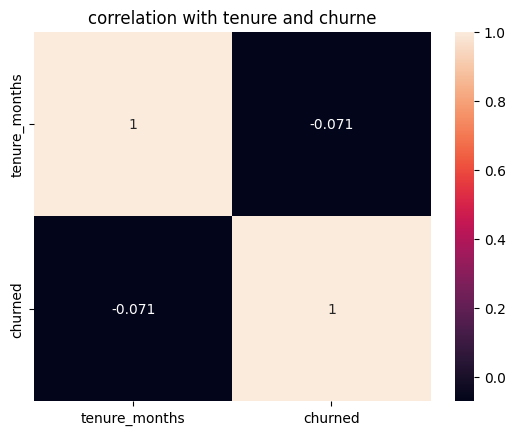

In [19]:
correlation=df[['tenure_months','churned']].corr()

sns.heatmap(data=correlation,annot=True)
plt.title('correlation with tenure and churne',color='black')
print('Veru poor realationshipe tenure and churned')


In [20]:
df.head(2)

,customer_id,operator,plan_type,region,customer_segment,device_type,network_type,internet_plan,payment_method,tenure_months,...,vas_subscribed,auto_renewal,activation_date,last_recharge_date,complaint_type,nps_score,churned,year,month,day
0,BD0000001,Grameenphone,Prepaid,Dhaka,Student,Smartphone (Premium),2G,1GB/day,Auto Debit,73,...,0,0,2022-08-17,2022-01-08,No Complaint,5,1,2022,8,17
1,BD0000002,Teletalk,Prepaid,Chattogram,Student,Smartphone (Budget),4G,2GB/day,Credit Card,2,...,0,0,2022-02-21,2022-04-22,Data Speed,9,0,2022,2,21


#  Which internet plans are most popular among customers?




In [21]:
(df.groupby('internet_plan')['customer_id'].count().
    sort_values(ascending=False).reset_index().
        rename(columns={'customer_id':'customer_count'}))


,internet_plan,customer_count
0,1GB/day,25077
1,2GB/day,20170
2,5GB/day,14888
3,10GB/day,10026
4,No Data,9939
5,30GB/month,9850
6,50GB/month,5924
7,Unlimited,4126


#  Do customers with higher monthly bills churn more often?




In [22]:
(df.groupby('churned')['monthly_bill_bdt'].sum(). sort_values(ascending=False).
    reset_index().rename(columns={'monthly_bill_bdt':'monthly bill'}))

,churned,monthly bill
0,0,37319237.38
1,1,3192101.68


#  How does data usage vary across customer segments?


  customer_segment  data_usage_gb_monthly
0          Student              81667.508
1         Business              67773.463
2            Rural              52700.023
3            Urban              40453.372
4           Senior              26390.015


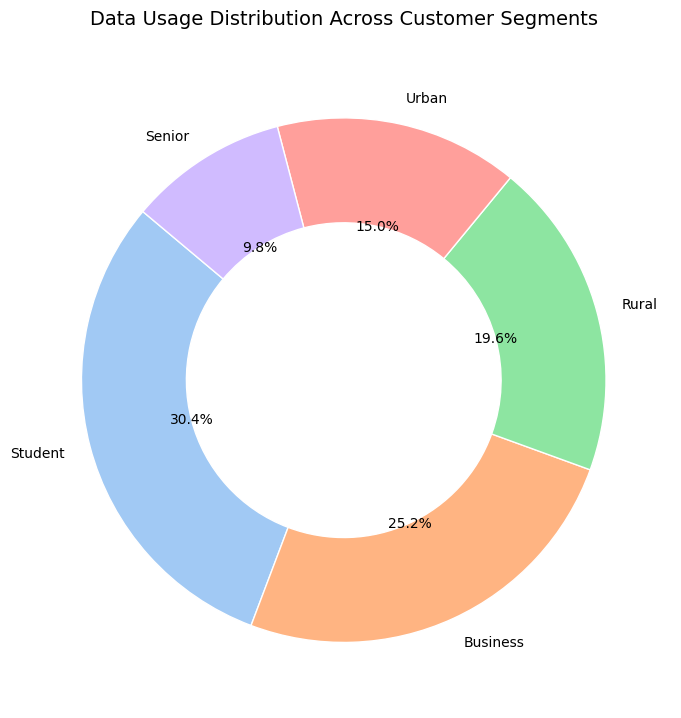

In [23]:
group=(df.groupby('customer_segment')['data_usage_gb_monthly'].sum(). sort_values(ascending=False).
    reset_index())
print(group)

import matplotlib.pyplot as plt
import seaborn as sns


colors = sns.color_palette('pastel')[0:len(group)]


plt.figure(figsize=(7, 8))
plt.pie(
    group['data_usage_gb_monthly'], 
    labels=group['customer_segment'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w') 
)

plt.title('Data Usage Distribution Across Customer Segments', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#  Which payment methods are preferred by customers?




In [24]:
(df.groupby('payment_method')['customer_id'].count().
    sort_values(ascending=False).
        reset_index().
            rename(columns={'customer_id':'customers count'}))

,payment_method,customers count
0,Mobile Banking (bKash),40117
1,Mobile Banking (Nagad),24933
2,Cash,14907
3,Credit Card,8062
4,Auto Debit,7036
5,Rocket,4945


#  Are customers using Auto Renewal more loyal?




In [25]:
result=(df.groupby("auto_renewal")["churned"].mean() * 100).sort_values(ascending=False).reset_index().rename(columns={'churned':'churned rate'})

print(("Insight: Customers using Auto Renewal have a "
"slightly lower churn rate (8.04%) thancustomers without Auto Renewal (8.52%)." 
"However, the difference is very small,suggesting that"
"Auto Renewal alone is not a strong predictor of customer  loyalty.",result))

('Insight: Customers using Auto Renewal have a slightly lower churn rate (8.04%) thancustomers without Auto Renewal (8.52%).However, the difference is very small,suggesting thatAuto Renewal alone is not a strong predictor of customer  loyalty.',    auto_renewal  churned rate
0             0      8.516323
1             1      8.039622)


#  Which complaint types occur most frequently?



In [26]:
(df.groupby('complaint_type')['customer_id'].count().
    sort_values(ascending=False).
        reset_index().rename(columns={'customer_id':'complaint'}))

,complaint_type,complaint
0,No Complaint,65233
1,Network Issue,9892
2,Billing Error,7953
3,Customer Service,7058
4,Data Speed,5878
5,Call Drop,3986


#  Which complaint types lead to the highest churn?


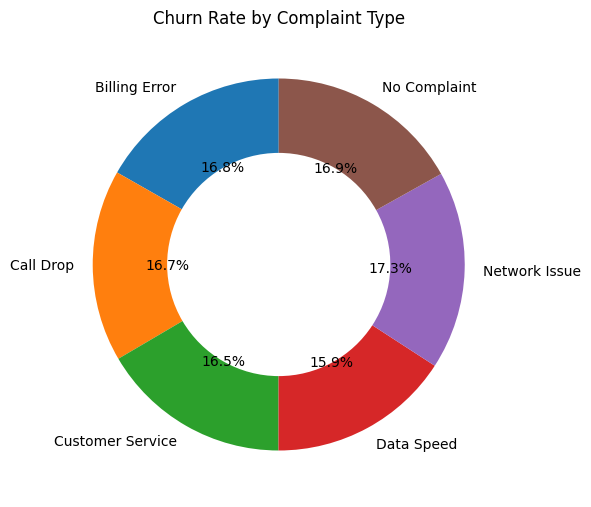

In [27]:


complaint_churn = (
    df.groupby("complaint_type")["churned"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(6, 10))

plt.pie(
    complaint_churn,
    labels=complaint_churn.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}   
)

plt.title("Churn Rate by Complaint Type")


plt.show()

#  Does VAS subscription increase customer retention?




In [28]:

pd.crosstab(df['vas_subscribed'], df['churned'], normalize='index')* 100

churned,0,1
vas_subscribed,,
0,91.710680,8.289320
1,91.781874,8.218126


#  Which regions generate the highest data consumption?




In [29]:
(df.groupby('region')['data_usage_gb_monthly'].sum().
    sort_values(ascending=False).
        reset_index().
            rename(columns={'data_usage_gb_monthly':'highest use data'}).round(2))

,region,highest use data
0,Dhaka,94291.82
1,Chattogram,53595.40
2,Rajshahi,32740.19
3,Khulna,26918.07
4,Sylhet,21408.31
5,Barisal,16128.31
6,Rangpur,12947.08
7,Mymensingh,10955.20


In [30]:
df.head(1)

,customer_id,operator,plan_type,region,customer_segment,device_type,network_type,internet_plan,payment_method,tenure_months,...,vas_subscribed,auto_renewal,activation_date,last_recharge_date,complaint_type,nps_score,churned,year,month,day
0,BD0000001,Grameenphone,Prepaid,Dhaka,Student,Smartphone (Premium),2G,1GB/day,Auto Debit,73,...,0,0,2022-08-17,2022-01-08,No Complaint,5,1,2022,8,17


#  How does roaming usage impact monthly spending?




In [31]:
(df.groupby('roaming_enabled')['monthly_bill_bdt'].sum().
     sort_values(ascending=False).
        reset_index().
            rename(columns={'monthly_bill_bdt':' monthly spending'}).round(2))

,roaming_enabled,monthly spending
0,0,34375749.60
1,1,6135589.46


#  Which network type (3G/4G/5G) provides the highest customer satisfaction?


In [32]:
(df.groupby('network_type').agg({
    'customer_id':'count',
    'monthly_bill_bdt':'sum'
    
}).sort_values(by='monthly_bill_bdt',ascending=False).
    reset_index().
        rename(columns={'customer_id':'customer count','monthly_bill_bdt':'monthly bill'}))

,network_type,customer count,monthly bill
0,4G,70144,28357173.90
1,3G,14952,6121067.81
2,5G,9984,4003107.25
3,2G,4920,2029990.10


# What factors are most correlated with NPS score?



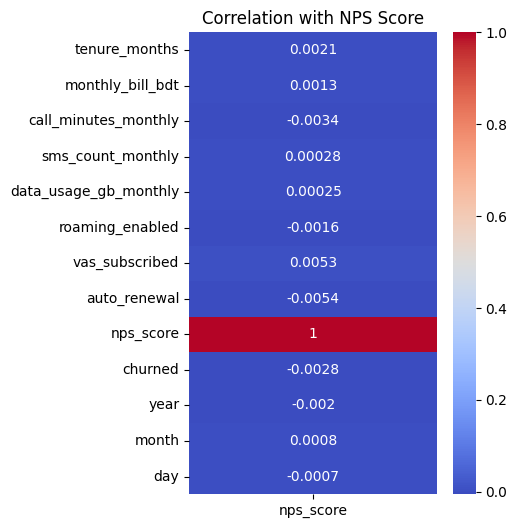

In [33]:

plt.figure(figsize=(4, 6))
sns.heatmap(df.corr(numeric_only=True)[['nps_score']], annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with NPS Score')
plt.show()

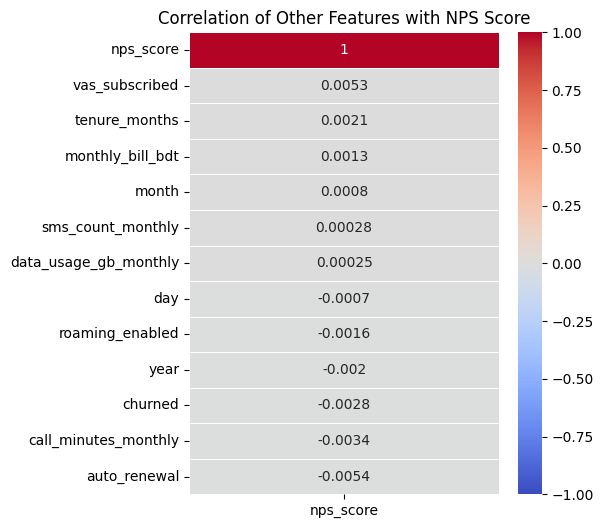

In [34]:
plt.figure(figsize=(5, 6))
nps_corr = df.corr(numeric_only=True)[['nps_score']].sort_values(by='nps_score', ascending=False)
sns.heatmap(nps_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation of Other Features with NPS Score')
plt.show()

#  Can we predict customer churn using machine learning?




In [60]:
model_df=df.copy()

In [ ]:
model_df.info()

In [65]:

plan_mapping = {
    'No Data': 0,
    '30GB/month': 1,
    '1GB/day': 2,      
    '50GB/month': 3,
    '2GB/day': 4,     
    '5GB/day': 5,   
    '10GB/day': 6,     
    'Unlimited': 7
}


model_df['internet_plan_int'] = model_df['internet_plan'].map(plan_mapping)

In [66]:
model_df.drop(columns=['internet_plan'],inplace=True)

In [67]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            100000 non-null  object        
 1   operator               100000 non-null  object        
 2   plan_type              100000 non-null  object        
 3   region                 100000 non-null  object        
 4   customer_segment       100000 non-null  object        
 5   device_type            100000 non-null  object        
 6   network_type           100000 non-null  object        
 7   payment_method         100000 non-null  object        
 8   tenure_months          100000 non-null  int64         
 9   monthly_bill_bdt       100000 non-null  float64       
 10  call_minutes_monthly   100000 non-null  float64       
 11  sms_count_monthly      100000 non-null  int64         
 12  data_usage_gb_monthly  100000 non-null  float

In [68]:
plan_mappings = {
    '2G':0,
    '4G':1,
    '5G':2,
    '3G':3
}

model_df['network_type']=model_df['network_type'].map(plan_mappings)

In [69]:
model_df.head(2)

,customer_id,operator,plan_type,region,customer_segment,device_type,network_type,payment_method,tenure_months,monthly_bill_bdt,...,data_usage_gb_monthly,roaming_enabled,vas_subscribed,auto_renewal,activation_date,last_recharge_date,complaint_type,nps_score,churned,internet_plan_int
0,BD0000001,Grameenphone,Prepaid,Dhaka,Student,Smartphone (Premium),0,Auto Debit,73,285.88,...,0.380,0,0,0,2022-08-17,2022-01-08,No Complaint,5,1,2
1,BD0000002,Teletalk,Prepaid,Chattogram,Student,Smartphone (Budget),1,Credit Card,2,464.93,...,0.721,1,0,0,2022-02-21,2022-04-22,Data Speed,9,0,4


In [70]:
model_df['payment_method'].unique()

array(['Auto Debit', 'Credit Card', 'Mobile Banking (bKash)', 'Rocket',
       'Cash', 'Mobile Banking (Nagad)'], dtype=object)

In [71]:

payment_mapping = {
    'Cash': 0,
    'Auto Debit': 1,
    'Credit Card': 2,
    'Rocket': 3,
    'Mobile Banking (bKash)': 4,
    'Mobile Banking (Nagad)': 5
}


model_df['payment_method_int'] = model_df['payment_method'].map(payment_mapping)


model_df = model_df.drop(columns=['payment_method'])

In [72]:
model_df.head()

,customer_id,operator,plan_type,region,customer_segment,device_type,network_type,tenure_months,monthly_bill_bdt,call_minutes_monthly,...,roaming_enabled,vas_subscribed,auto_renewal,activation_date,last_recharge_date,complaint_type,nps_score,churned,internet_plan_int,payment_method_int
0,BD0000001,Grameenphone,Prepaid,Dhaka,Student,Smartphone (Premium),0,73,285.88,41.9,...,0,0,0,2022-08-17,2022-01-08,No Complaint,5,1,2,1
1,BD0000002,Teletalk,Prepaid,Chattogram,Student,Smartphone (Budget),1,2,464.93,181.1,...,1,0,0,2022-02-21,2022-04-22,Data Speed,9,0,4,2
2,BD0000003,Banglalink,Prepaid,Dhaka,Student,Feature Phone,2,1,324.40,329.0,...,0,0,0,2023-07-18,2024-06-21,No Complaint,10,0,5,4
3,BD0000004,Robi,Prepaid,Chattogram,Business,Smartphone (Premium),1,14,280.97,54.5,...,0,0,0,2023-05-17,2024-06-21,No Complaint,3,0,7,3
4,BD0000005,Grameenphone,Prepaid,Dhaka,Urban,Smartphone (Budget),3,41,518.59,3.1,...,1,0,0,2023-04-03,2023-05-12,No Complaint,5,0,5,0


In [73]:

device_mapping = {
    'Feature Phone': 0,
    'Smartphone (Budget)': 1,
    'Smartphone (Mid)': 2,
    'Smartphone (Premium)': 3
}
model_df['device_type_int'] = model_df['device_type'].map(device_mapping)
model_df = model_df.drop(columns=['device_type'])

In [74]:

columns_to_encode = ['operator', 'plan_type', 'region', 'customer_segment','complaint_type']

model_df = pd.get_dummies(model_df, columns=columns_to_encode, dtype=int)

In [75]:
model_df.columns

Index(['customer_id', 'network_type', 'tenure_months', 'monthly_bill_bdt',
       'call_minutes_monthly', 'sms_count_monthly', 'data_usage_gb_monthly',
       'roaming_enabled', 'vas_subscribed', 'auto_renewal', 'activation_date',
       'last_recharge_date', 'nps_score', 'churned', 'internet_plan_int',
       'payment_method_int', 'device_type_int', 'operator_Airtel',
       'operator_Banglalink', 'operator_Grameenphone', 'operator_Robi',
       'operator_Teletalk', 'plan_type_Postpaid', 'plan_type_Prepaid',
       'region_Barisal', 'region_Chattogram', 'region_Dhaka', 'region_Khulna',
       'region_Mymensingh', 'region_Rajshahi', 'region_Rangpur',
       'region_Sylhet', 'customer_segment_Business', 'customer_segment_Rural',
       'customer_segment_Senior', 'customer_segment_Student',
       'customer_segment_Urban', 'complaint_type_Billing Error',
       'complaint_type_Call Drop', 'complaint_type_Customer Service',
       'complaint_type_Data Speed', 'complaint_type_Network Issue

In [76]:
model_df.drop(columns=['customer_id'],inplace=True)

In [77]:
model_df.head(2)

,network_type,tenure_months,monthly_bill_bdt,call_minutes_monthly,sms_count_monthly,data_usage_gb_monthly,roaming_enabled,vas_subscribed,auto_renewal,activation_date,...,customer_segment_Rural,customer_segment_Senior,customer_segment_Student,customer_segment_Urban,complaint_type_Billing Error,complaint_type_Call Drop,complaint_type_Customer Service,complaint_type_Data Speed,complaint_type_Network Issue,complaint_type_No Complaint
0,0,73,285.88,41.9,35,0.380,0,0,0,2022-08-17,...,0,0,1,0,0,0,0,0,0,1
1,1,2,464.93,181.1,25,0.721,1,0,0,2022-02-21,...,0,0,1,0,0,0,0,1,0,0


In [78]:
model_df.drop(columns=['activation_date','last_recharge_date'],inplace=True)

In [79]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   network_type                     100000 non-null  int64  
 1   tenure_months                    100000 non-null  int64  
 2   monthly_bill_bdt                 100000 non-null  float64
 3   call_minutes_monthly             100000 non-null  float64
 4   sms_count_monthly                100000 non-null  int64  
 5   data_usage_gb_monthly            100000 non-null  float64
 6   roaming_enabled                  100000 non-null  int64  
 7   vas_subscribed                   100000 non-null  int64  
 8   auto_renewal                     100000 non-null  int64  
 9   nps_score                        100000 non-null  int64  
 10  churned                          100000 non-null  int64  
 11  internet_plan_int                100000 non-null  int64  
 12  pay

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [81]:
x=model_df.drop('churned',axis=1)
y=model_df['churned']

In [82]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [89]:

model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,       
    min_samples_split=5, 
    min_samples_leaf=2,   
    random_state=42
)

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [92]:
model.score(x_train,y_train)

0.9167375

In [93]:
y_pred=model.predict(x_test)

# accuracy score

In [94]:
accuracy_score(y_test,y_pred)

0.91965

# confusion metrix

In [95]:
confusion_matrix(y_test,y_pred)

array([[18393,     0],
       [ 1607,     0]])

# classifier report

In [99]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     18393
           1       0.00      0.00      0.00      1607

    accuracy                           0.92     20000
   macro avg       0.46      0.50      0.48     20000
weighted avg       0.85      0.92      0.88     20000



# feature importance

In [102]:
importance=pd.DataFrame({
    'feature':x.columns,
    'importance':model.feature_importances_
}).sort_values(by='importance',ascending=False)
importance

,feature,importance
1,tenure_months,0.292846
2,monthly_bill_bdt,0.112809
3,call_minutes_monthly,0.089571
5,data_usage_gb_monthly,0.081473
4,sms_count_monthly,0.062375
12,device_type_int,0.062149
9,nps_score,0.038608
10,internet_plan_int,0.032504
11,payment_method_int,0.026349
0,network_type,0.017485
